# CMSE 381 Final Project Template

**INSTRUCTIONS**: This is a template to help organize your project.  All projects should include the 5 major sections below (you do not need to use this template file).  If you use this file, complete your work below and remove content in parentheses. Also, remove this current cell.  

#### CMSE 381 Final Project
### &#9989; Group members: Jack Bansen, Logan Pearson
### &#9989; Section_002
#### &#9989; 4/24/2026

# ___How Factors Can Be Used to Predict Students Performace___

## Background and Motivation

_(Provide context for the problem.  **Clearly state the question(s) you set
out to answer.**)_

This dataset contains student academic performance data and related demographic and behavioral factors. The goal is to understand which variables are most strongly associated with student performance, and to build predictive models for academic outcomes.
Our goal is to answer the questions: Which factor has the greatest correlation with student performance? Which factors have a postive or negative effect on student performance? Which factors have the highest correlation with high performace and vis verca?

## Methodology
_(How did you go about answering your question(s)? You should wrote some code here to demonstrate what the data is like and how in principle your method works. You can leave the variations of the related to specific results to the results section.)_

In [132]:
# you may want to import some modules here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV, KFold
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score

### Data
_(Describe the data you are using. What variables are you using? What they mean? Why did you choose them?)_

In [65]:
# you may need some code here to adjust the format or organization of your data so that they can be used for the model
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [67]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Hours_Studied               6607 non-null   int64 
 1   Attendance                  6607 non-null   int64 
 2   Parental_Involvement        6607 non-null   object
 3   Access_to_Resources         6607 non-null   object
 4   Extracurricular_Activities  6607 non-null   object
 5   Sleep_Hours                 6607 non-null   int64 
 6   Previous_Scores             6607 non-null   int64 
 7   Motivation_Level            6607 non-null   object
 8   Internet_Access             6607 non-null   object
 9   Tutoring_Sessions           6607 non-null   int64 
 10  Family_Income               6607 non-null   object
 11  Teacher_Quality             6529 non-null   object
 12  School_Type                 6607 non-null   object
 13  Peer_Influence              6607 non-null   obje

The data has a mix of categorical and numerical features. The data has 20 different variables. We are choosing the exam score as the output variable in this case as we believe it best represents a students grade/performance in a class compared to the other variables. We chose the variables: 

In [70]:
# check for missing values
print(df.isna().sum())

target = "Exam_Score"
X = df.drop(columns=target)
y = df[target]

numeric_features = X.select_dtypes(include=["int64", "float64"]).columns.tolist()
categorical_features = X.select_dtypes(include=["object", "string"]).columns.tolist()

print("\nNumeric features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

Numeric features:
['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores', 'Tutoring_Sessions', 'Physical_Activity']

Categorical features:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Inf

In [72]:
# preprocessing 
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [74]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=67
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5285, 19)
X_test shape: (1322, 19)
y_train shape: (5285,)
y_test shape: (1322,)


### Models for classification: Random Forest
_(What models will you be using for classification? Why did you choose to use them? What questions would you answer with them? How would you evaluate if each model? What cross-validation method did you use?)_

We will be using Decision Trees as it handles categorical data pretty well and is relatively easy to interpret. Another model for classification is Random Forests as it works well with mixed data of categorical and numerical, it also is good with nonlinearity and is robust. These models would help answer: Which factors have a postive or negative effect on student performance, and Which factor has the greatest correlation with student performance?. Each model can validated using its accuracy score or F1 score as well as a 5 or 10 fold Stratified K-Fold to optimal estimates on predictability.

In [115]:
#Baseline Model
rf_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier())
])

df["Grade"] = pd.cut(
    df["Exam_Score"],
    bins=[0, 60, 70, 80, 100],
    labels=["D", "C", "B", "A"] 
)

df_c = df.dropna(subset=["Grade"])
X_c = df_c.drop(["Exam_Score", "Grade"], axis=1)
y_c = df_c["Grade"]

X_c_train, X_c_test, y_c_train, y_c_test = train_test_split(
    X_c, y_c, test_size=0.2, stratify=y_c
)

rf_model.fit(X_c_train, y_c_train)
y_c_pred = rf_model.predict(X_c_test)

print("Accuracy:", accuracy_score(y_c_test, y_c_pred))
print("\nClassification Report:\n", classification_report(y_c_test, y_c_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_c_test, y_c_pred))

Accuracy: 0.8888048411497731

Classification Report:
               precision    recall  f1-score   support

           A       0.00      0.00      0.00         8
           B       0.92      0.51      0.66       208
           C       0.89      0.99      0.94      1077
           D       0.00      0.00      0.00        29

    accuracy                           0.89      1322
   macro avg       0.45      0.38      0.40      1322
weighted avg       0.87      0.89      0.87      1322


Confusion Matrix:
 [[   0    0    8    0]
 [   0  107  101    0]
 [   0    9 1068    0]
 [   0    0   29    0]]


C:\Users\banfa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\banfa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\banfa\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [117]:
#Basic K-Fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(rf_model, X_c, y_c, cv=cv, scoring="f1_macro")

print("F1 scores for each fold:", scores)
print("Average F1:", np.mean(scores))

F1 scores for each fold: [0.41018491 0.40357303 0.39961659 0.41027292 0.40934974]
Average F1: 0.40659943724382


In [113]:
#Model Selection
param_grid = {
    "classifier__n_estimators": [100, 200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5]
}

grid = GridSearchCV(rf_model, param_grid, cv=cv, scoring="f1_macro",n_jobs=-1)

grid.fit(X_c, y_c)

print("Best params:", grid.best_params_)
print("Best score:", grid.best_score_)

Best params: {'classifier__max_depth': 20, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Best score: 0.41325696084062286


In [94]:
#Best Model
best_model = grid.best_estimator_

best_model.fit(X_c_train, y_c_train)
y_c_pred = best_model.predict(X_c_test)

### Models for regression: Milti Linear Regression
_(What models will you be using for regression? Why did you choose to use them? What questions would you answer with them? How would you evaluate if each model? What cross-validation method did you use?)_

In [8]:
# Baseline Linear Regression with all features
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

lr_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

lr_model.fit(X_train, y_train)
y_pred = lr_model.predict(X_test)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f}")
print(f"R^2:  {r2:.3f}")

RMSE: 2.073
R^2:  0.719


In [9]:
# Ridge regression with 5-fold CV to choose alpha
ridge_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", Ridge())
])

alpha_grid = {"model__alpha": [0.001, 0.01, 0.1, 1, 10, 100]}

kf = KFold(n_splits=5, shuffle=True, random_state=381)

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid=alpha_grid,
    cv=kf,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1
)

ridge_search.fit(X_train, y_train)

print("Best alpha:", ridge_search.best_params_["model__alpha"])
print("Best CV RMSE:", round(-ridge_search.best_score_, 3))

Best alpha: 1
Best CV RMSE: 2.008


In [10]:
from sklearn.metrics import mean_squared_error, r2_score

best_ridge_model = ridge_search.best_estimator_
ridge_y_pred = best_ridge_model.predict(X_test)

# test metrics
ridge_rmse = mean_squared_error(y_test, ridge_y_pred) ** 0.5
ridge_r2 = r2_score(y_test, ridge_y_pred)

print("Ridge Regression Test Results:")
print(f"RMSE: {ridge_rmse:.3f}")
print(f"R^2: {ridge_r2:.3f}")

Ridge Regression Test Results:
RMSE: 2.073
R^2: 0.719


In [11]:
from sklearn.model_selection import cross_val_score

# 5-fold CV comparison: baseline linear regression vs tuned ridge regression

# baseline linear regression CV
lr_cv_rmse = -cross_val_score(
    lr_model,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

lr_cv_r2 = cross_val_score(
    lr_model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

# ridge regression CV using the best tuned model
ridge_cv_rmse = -cross_val_score(
    best_ridge_model,
    X,
    y,
    cv=kf,
    scoring="neg_root_mean_squared_error"
)

ridge_cv_r2 = cross_val_score(
    best_ridge_model,
    X,
    y,
    cv=kf,
    scoring="r2"
)

print("5-Fold CV Comparison:")
print(f"Baseline Linear Regression Mean RMSE: {lr_cv_rmse.mean():.3f}")
print(f"Baseline Linear Regression Mean R^2: {lr_cv_r2.mean():.3f}")
print()
print(f"Ridge Regression Mean RMSE: {ridge_cv_rmse.mean():.3f}")
print(f"Ridge Regression Mean R^2: {ridge_cv_r2.mean():.3f}")
print(f"Best Ridge alpha: {ridge_search.best_params_['model__alpha']}")

5-Fold CV Comparison:
Baseline Linear Regression Mean RMSE: 2.041
Baseline Linear Regression Mean R^2: 0.724

Ridge Regression Mean RMSE: 2.041
Ridge Regression Mean R^2: 0.724
Best Ridge alpha: 1


### Other methods used _(if applicable)_

_(If this is a preprocessing step to prepare your data for regression or classification models, you should put this subsection before your explanation for the regression or classification models.)_

_(What method did you use otherwise? Why did you choose to use them? What questions would you answer with them? How would you evaluate the results? What cross-validation method did you use when applicable?)_

In [12]:
# you may add some code here to show how the method works in principle

## Results

_(What did you find when you carried out your methods? Some of your code related to
presenting results/figures/data may be replicated from the methods section or may only be present in
this section. All of the plots that you plan on using for your presentation should be present in this
section)_

### classification results
_(What are you trying to do here?)_

Our goal for classification analysis was to be able to predict student performance in categories (grades A, B, C, D) using a Random Forest classification model. We aimed to be able to determine how well student attributes predict final grades as well as how to identify which features are most important. Most importantly evaluate how accurately the model distinguishes between grade levels.

_(How do you interpret what you see?)_

_(What are you doing next?)_

The Random Forest model achieved an `Accuracy` of  0.8888, and a  `Cross-validated F1-score` of 0.40

The `Accuracy` is decent but the `F1-Score` is moderate at best. However, it does tend to do better than guessing as it guessing would give a score of 0.25 so it is definetly better than guessing but does struggle to seperate grades. The next step would be to apply Stratified K-Fold to help increase the `F1-score` of the model.

After Stratified K-Fold the model only improved slightly as the `F1-score` increased to 0.4133. While this is improvement it still is moderate when it comes to its predictability. The hyperparameters (300 trees and maximum depth of 20) suggest that the model benefits from increased complexity, though this can lead to more overfitting of the data. I believe that the moderate performance is likely due to overlapping grade boundaries and limited predictive features.

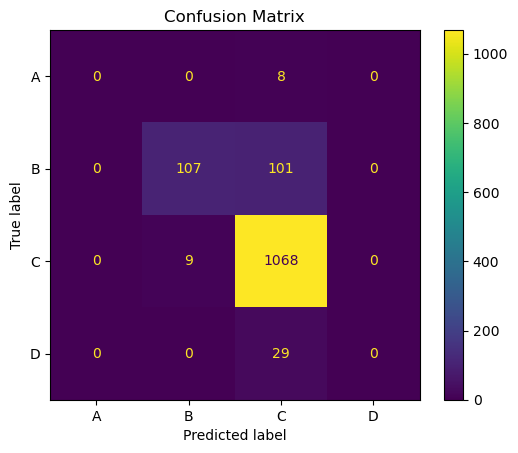

In [134]:
cm = confusion_matrix(y_c_test, y_c_pred, labels=["A","B","C","D"])

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["A","B","C","D"])
disp.plot()
plt.title("Confusion Matrix")
plt.show()

Most errors occur between adjacent grades such as B and A, or C and B

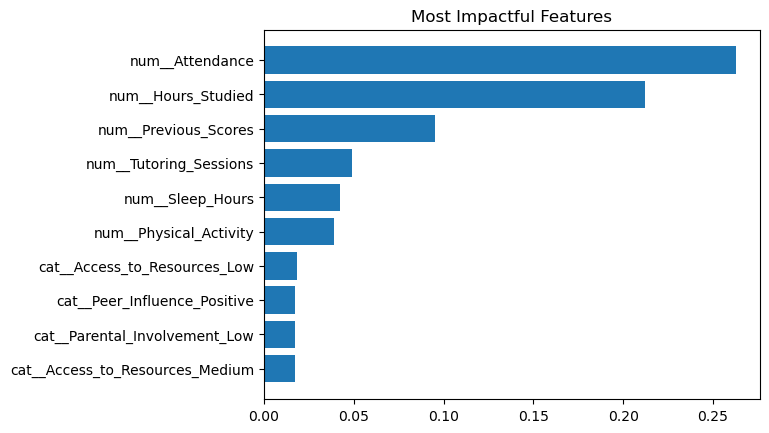

In [138]:
rf = best_model.named_steps["classifier"]
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()

importances = rf.feature_importances_

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values(by="importance", ascending=False).head(10)

plt.barh(feat_imp["feature"], feat_imp["importance"])
plt.gca().invert_yaxis()
plt.title("Most Impactful Features")
plt.show()

The `Attendance` of a student seems to be the most impactful predictor of a student `Exam_Score` with the `Number of Hours studied` close behind. The graph also shows which predictors are the least impactful like `Access to Resources`, `positive peer influence` and `low parental involvement`.   

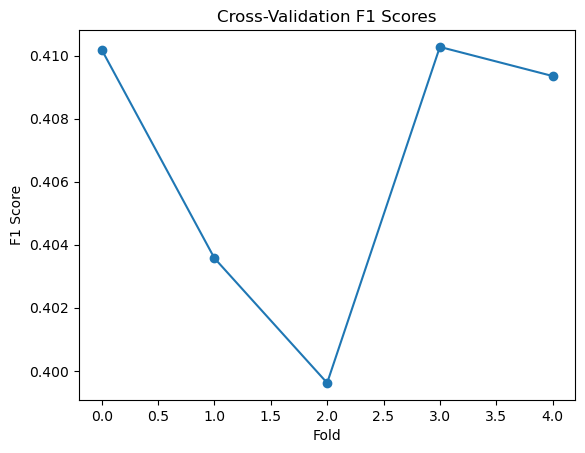

In [140]:
plt.plot(scores, marker='o')
plt.title("Cross-Validation F1 Scores")
plt.xlabel("Fold")
plt.ylabel("F1 Score")
plt.show()

The variation in `F1-Scores` suggests that the data in sensitive to splits and can be quite volatile.

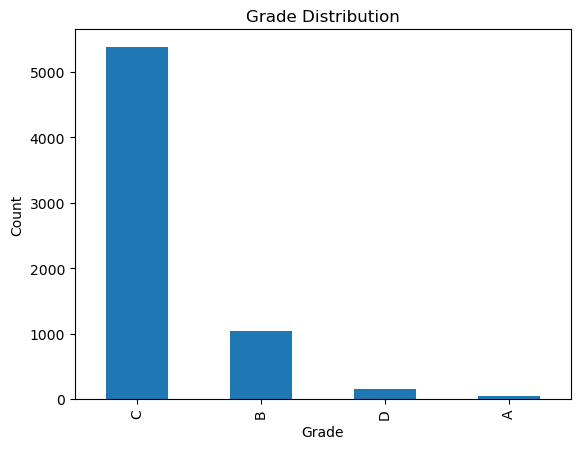

In [142]:
df_c["Grade"].value_counts().plot(kind="bar")
plt.title("Grade Distribution")
plt.xlabel("Grade")
plt.ylabel("Count")
plt.show()

The dataset is heavily imbalanced with C grades making up more than all the other classifications together. This in turn can greatly affect the  performance of the model helping to explain why the `F1-Score` was so low.

### Regression Results
_(What are you trying to do here?)_

_(How do you interpret what you see?)_

_(What are you doing next?)_

Initially we used a baseline multiple linear regression model which included all input features to predict the quantitative outcome `Exam_Score`. We chose to use this model because `Exam_Score` is a numerical variable, so multiple linear regression gave us a simple baseline model to see how well all of the input features could predict exam performance. The main question we wanted to answer with this model was how well the available student-related factors could predict `Exam_Score`.

In order to attempt an improvement, we then used K-fold Cross Validation to select the Ridge parameter `alpha`, and then used Ridge regression for better parameter tuning that could potentially lead to a better model. We chose to use Ridge regression because it is closely related to linear regression, but it also allows parameter tuning through regularization, which can sometimes improve model performance. We evaluated both models using RMSE and R², and we used K-fold Cross Validation to tune the Ridge model.

The results were that the Ridge regression model performed identically to the baseline model with no improvements, both with an RMSE of 2.041 and an R² of 0.724.

### other results
_(What are you trying to do here?)_

In [17]:
# how did you do it

_(How do you interpret what you see?)_

_(What are you doing next?)_

In [18]:
# how did you do it (etc. etc.)

## Discussion and Conclusion

_(What did you learn from your results? What obstacles did you run into? What would you do differently next time? Clearly provide quantitative answers to your question(s)?  At least one of your questions should be answered with numbers.  That is, it is not sufficient to answer "yes" or "no", but rather to say something quantitative such as variable 1 increased roughly 10% for every 1 year increase in variable 2.)_

### Discussion on the Classification Results

We leared that it's possible to create models that can learn patterns of data but can also struggle a lot too especiall when it comes to determining classification for quantitative values. The Random Forest model did do better than guessing as that would lead to a F1-Score of .25 compared to the models .406 F1-Score which is `62.4%` better and that these scores can be slightly improved. With the use of stratified k-fold the model did see a slight increase to .413 which would then be `65.2%` better than guessing. Although this is marginally better than the original it still shows that the models can be improved. On top of the model not being great other issues included missing data points and a heavy imbalance in which grades appeared in data set. Another obstacle was the fact that grade boundaries can be very close when comparing grades of 79 vs 80 which would hurt the predictability of the model. In the future we would probably use a different classification category like passing or failing or a more arbitrary good, average, or bad classifications that allow for more leeway with the data set provided.

### discussion on the regression results

### discussion on the other results

### conclusion and future steps

## Author contribution

_(Please describe the contribution of each member of group)._

## References

_(List the source(s) for any data and/or literature cited in your project.  Ideally, this should be formatted using a formal citation format (MLA or APA or other, your choice!).   Multiple free online citation generators are available such as <a href="http://www.easybib.com/style">http://www.easybib.com/style</a>. **Important:** if you use **any** code that you find on the internet for your project you **must** cite it or you risk losing most/all of the points for you project.)_

Munch, Liz, et al. “CMSE381-002_Lec25_RandomForests.” Michigan State University. 

Munch, Liz, et al. “CMSE381/CMSE381-002_Lec15_kfold_Classification.” Michigan State University. 